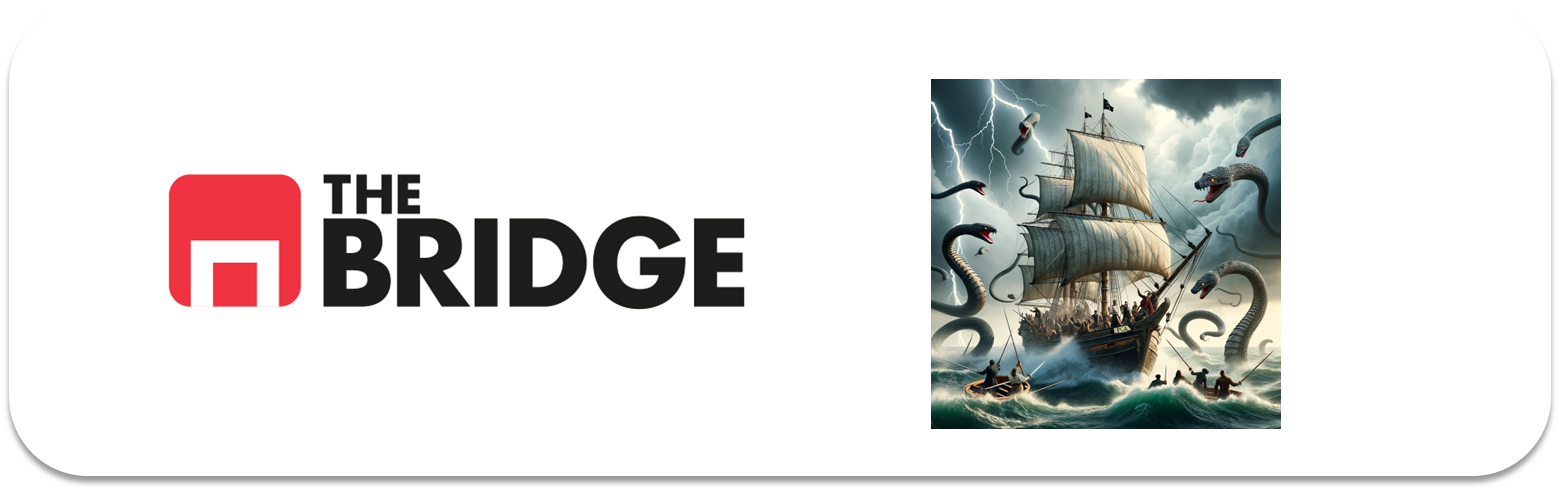

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 

In [68]:
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
df = pd.DataFrame(olivetti.data , columns=[f'pixel_{i}' for i in range(olivetti.data.shape[1])])
df['target'] = olivetti.target
df.head(20)

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9
5,0.520661,0.533058,0.541322,0.578512,0.623967,0.640496,0.648760,0.640496,0.648760,0.644628,...,0.425620,0.450413,0.400826,0.388430,0.367769,0.309917,0.371901,0.367769,0.355372,8
6,0.136364,0.119835,0.132231,0.111570,0.119835,0.123967,0.123967,0.128099,0.132231,0.144628,...,0.508264,0.619835,0.685950,0.479339,0.388430,0.533058,0.640496,0.657025,0.640496,32
7,0.247934,0.347107,0.466942,0.508264,0.574380,0.615702,0.669421,0.694215,0.710744,0.723140,...,0.070248,0.082645,0.078512,0.074380,0.082645,0.074380,0.111570,0.123967,0.119835,9
8,0.334711,0.388430,0.491736,0.623967,0.735537,0.764463,0.756198,0.764463,0.780992,0.801653,...,0.057851,0.082645,0.086777,0.078512,0.111570,0.107438,0.144628,0.161157,0.185950,26
9,0.285124,0.285124,0.272727,0.214876,0.169421,0.165289,0.264463,0.446281,0.491736,0.541322,...,0.342975,0.326446,0.322314,0.301653,0.289256,0.305785,0.301653,0.309917,0.314050,12


2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica

In [69]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42, stratify=df['target'])

3. Hacer un quick miniEDA o justificar el no hacerlo.

En primer lugar vemos si hay diferencias entre el número de muestras por cada clase (persona), tanto en el original como en el train. Al estar igualmente distribuidas, no habría ningún problema

In [70]:
df_samples_per_class = np.bincount(df['target'])
train_samples_per_class = np.bincount(y_train)
print(f"Muestras en el dataset original: {df_samples_per_class}")
print(f"Muestras por clase en el dataset de entrenamiento: {train_samples_per_class}")

Muestras en el dataset original: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]
Muestras por clase en el dataset de entrenamiento: [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8]


Cuando observamos los rangos de valores de cada pixel, podemos ver que ya está en escala 0-1, por lo que no haría falta escalado para el resto del análisis, puesto que ya está escalado

In [71]:
X_train.describe()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,...,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,0.399716,0.430436,0.469576,0.512590,0.550465,0.585343,0.618608,0.644719,0.662513,0.673825,...,0.365638,0.369809,0.365857,0.358213,0.338740,0.335615,0.332438,0.317045,0.309452,0.305604
std,0.177370,0.187762,0.193995,0.191925,0.188693,0.179123,0.168297,0.156611,0.148521,0.145685,...,0.163487,0.180044,0.181925,0.190009,0.185873,0.190127,0.195619,0.187476,0.183148,0.179549
min,0.086777,0.066116,0.090909,0.041322,0.107438,0.107438,0.115702,0.115702,0.119835,0.140496,...,0.049587,0.037190,0.053719,0.049587,0.033058,0.012397,0.049587,0.061983,0.061983,0.033058
25%,0.251033,0.264463,0.301653,0.376033,0.445248,0.511364,0.537190,0.581612,0.599174,0.611570,...,0.230372,0.222107,0.219008,0.198347,0.176653,0.173554,0.173554,0.173554,0.173554,0.169421
50%,0.388430,0.454545,0.504132,0.545455,0.578512,0.607438,0.648760,0.665289,0.677686,0.702479,...,0.369835,0.369835,0.359504,0.342975,0.322314,0.299587,0.293388,0.278926,0.256198,0.258264
75%,0.528926,0.574380,0.633264,0.661157,0.685950,0.711777,0.735537,0.748967,0.765496,0.776860,...,0.483471,0.492769,0.496901,0.501033,0.480372,0.463843,0.459711,0.431818,0.409091,0.419421
max,0.805785,0.822314,0.834711,0.855372,0.859504,0.859504,0.871901,0.867769,0.871901,0.871901,...,0.793388,0.904959,0.888430,0.896694,0.822314,0.785124,0.921488,0.929752,0.884298,0.822314


Todas las columnas son numéricas y no hay nulos, por lo que no habría que tocar nada

In [72]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 320 entries, 383 to 85
Columns: 4096 entries, pixel_0 to pixel_4095
dtypes: float32(4096)
memory usage: 5.0 MB


In [73]:
X_train.isnull().sum()

pixel_0       0
pixel_1       0
pixel_2       0
pixel_3       0
pixel_4       0
             ..
pixel_4091    0
pixel_4092    0
pixel_4093    0
pixel_4094    0
pixel_4095    0
Length: 4096, dtype: int64

Estudiamos la distribucion de los datos, usando todos los valores como una sola variable. Se observa que se trata de una distribución normal desviada hacia colores oscuros (más cercanos a 1).

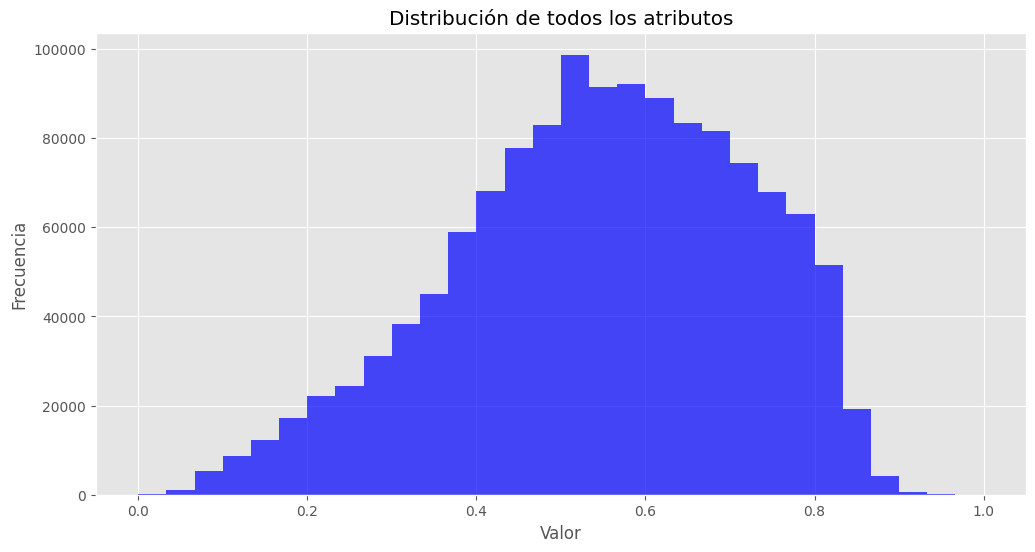

In [74]:
X_train.values.flatten()
plt.hist(X_train.values.flatten(), bins=30, color='blue', alpha=0.7)
plt.title('Distribución de todos los atributos')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()


4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes

In [75]:
# Hacemos un RandomForestClassifier sin PCA para tener un baseline de referencia
clf_base = RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42, n_jobs=-1)

# Balanced accuracy en CV con 5 folds
cv_scores_base = cross_val_score(clf_base, X_train, y_train, cv=5, scoring='balanced_accuracy')
baseline_cv    = np.mean(cv_scores_base)

# Balanced accuracy en test
clf_base.fit(X_train, y_train)
baseline_test = balanced_accuracy_score(y_test, clf_base.predict(X_test))

print("=" * 55)
print("BASELINE  (todas las features originales — sin PCA)")
print("=" * 55)
print(f"  Balanced Accuracy CV (5 folds): {baseline_cv:.4f}  ±  {np.std(cv_scores_base):.4f}")
print(f"  Balanced Accuracy Test:         {baseline_test:.4f}")

BASELINE  (todas las features originales — sin PCA)
  Balanced Accuracy CV (5 folds): 0.8075  ±  0.0584
  Balanced Accuracy Test:         0.8750


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:

1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).

In [76]:
num_features = X_train.shape[1]
print(f"\nNúmero de features originales: {num_features}")
# 1. PCA sin argumentos sobre X_train (sin especificar componentes ni varianza)
pca_model = PCA(random_state=42)
pca_model.fit(X_train)
print(f"Componentes calculados (= min(n_muestras_train, n_features)): {pca_model.n_components_}")
# Transformamos los datos
X_train_pca = pca_model.transform(X_train)
X_test_pca  = pca_model.transform(X_test)

print(f"\nNúmero de features después de PCA: {X_train_pca.shape[1]}")
X_train_pca.shape, X_test_pca.shape


Número de features originales: 4096
Componentes calculados (= min(n_muestras_train, n_features)): 320

Número de features después de PCA: 320


((320, 320), (80, 320))


Varianza explicada por cada componente principal: [2.42187992e-01 1.40496299e-01 7.82736614e-02 5.04177511e-02
 3.48525755e-02 3.28566805e-02 2.47333087e-02 1.99643485e-02
 1.97835900e-02 1.66696031e-02 1.49753820e-02 1.40897455e-02
 1.30255986e-02 1.15392366e-02 1.07033849e-02 9.80381761e-03
 9.46078170e-03 8.55978951e-03 7.90158194e-03 7.46427849e-03
 6.97004516e-03 6.59903744e-03 5.98014519e-03 5.76781761e-03
 5.38697047e-03 5.31599484e-03 5.11257211e-03 4.64378204e-03
 4.63828538e-03 4.35395632e-03 4.04663291e-03 3.87884374e-03
 3.71703925e-03 3.42301815e-03 3.31002707e-03 3.21940263e-03
 3.10560851e-03 2.96495925e-03 2.92400178e-03 2.81335786e-03
 2.67470977e-03 2.58739339e-03 2.47614295e-03 2.37473939e-03
 2.33397726e-03 2.30495445e-03 2.24506576e-03 2.19396874e-03
 2.13705353e-03 2.10699555e-03 2.02583475e-03 2.00966792e-03
 1.93495653e-03 1.89333514e-03 1.86281884e-03 1.80051289e-03
 1.74344331e-03 1.72655564e-03 1.67112984e-03 1.60238729e-03
 1.56936864e-03 1.55954715e-03 1.5

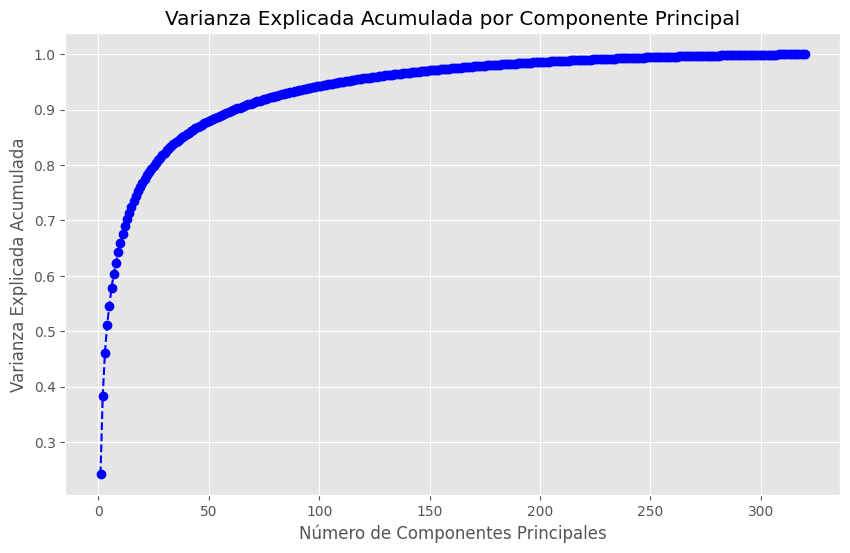

In [77]:
# Vemos la varianza explicada acumulada por cada componente principal
explained_variance_ratio = pca_model.explained_variance_ratio_
print(f"\nVarianza explicada por cada componente principal: {explained_variance_ratio}")
# Representamos la varianza explicada acumulada, mostrando los puntos y los valores de varianza explicada acumulada
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)

In [78]:
# Definimos el rango de reduccion de variables que queremos probar
percent_var = np.arange(0.2, 2.5, 0.3)
num_components = (percent_var * num_features/100).astype(int)
print(f"\nNúmero de componentes a probar: {num_components}")


Número de componentes a probar: [ 8 20 32 45 57 69 81 94]


3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.

In [79]:
# Hacemos el entreno de un modelo con cada una de las reducciones de variables, teniendo en cuenta que se encuentran en orden creciente de varianza explicada
results = []
k_model = RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42, n_jobs=-1)
for n_comp in num_components:
    X_k_train = X_train_pca[:, :n_comp]
    X_k_test  = X_test_pca[:, :n_comp]
    # Balanced accuracy en CV con 5 folds
    cv_score_k = cross_val_score(k_model, X_k_train, y_train, cv=5, scoring='balanced_accuracy').mean()
    k_model.fit(X_k_train, y_train)
    # Balanced accuracy en test
    test_score_k = balanced_accuracy_score(y_test, k_model.predict(X_k_test))
    results.append({
        'n_componentes':      n_comp,
        'score_cv':           round(cv_score_k, 4),
        'score_test':         round(test_score_k, 4),
        'compresion_%':       round(n_comp / num_features * 100, 4),
        'diff_cv_baseline':   round(cv_score_k   - baseline_cv,   4),
        'diff_test_baseline': round(test_score_k - baseline_test, 4)
    })


4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.

In [80]:
# Creamos la tabla de resultados a partir de la lista de diccionarios
result_tabla = pd.DataFrame(results)
# Mostramos los resultados
texto = "Resultados de la prueba de diferentes números de componentes:"
print("=" * len(texto))
print(texto)
print("=" * len(texto))
display(result_tabla.style.background_gradient(cmap='RdYlGn', subset=['score_cv', 'score_test', 'diff_cv_baseline', 'diff_test_baseline']))

Resultados de la prueba de diferentes números de componentes:


,n_componentes,score_cv,score_test,compresion_%,diff_cv_baseline,diff_test_baseline
0,8,0.725000,0.775000,0.195300,-0.082500,-0.100000
1,20,0.907500,0.862500,0.488300,0.100000,-0.012500
2,32,0.912500,0.912500,0.781200,0.105000,0.037500
3,45,0.907500,0.937500,1.098600,0.100000,0.062500
4,57,0.905000,0.887500,1.391600,0.097500,0.012500
5,69,0.907500,0.937500,1.684600,0.100000,0.062500
6,81,0.890000,0.912500,1.977500,0.082500,0.037500
7,94,0.900000,0.925000,2.294900,0.092500,0.050000


5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

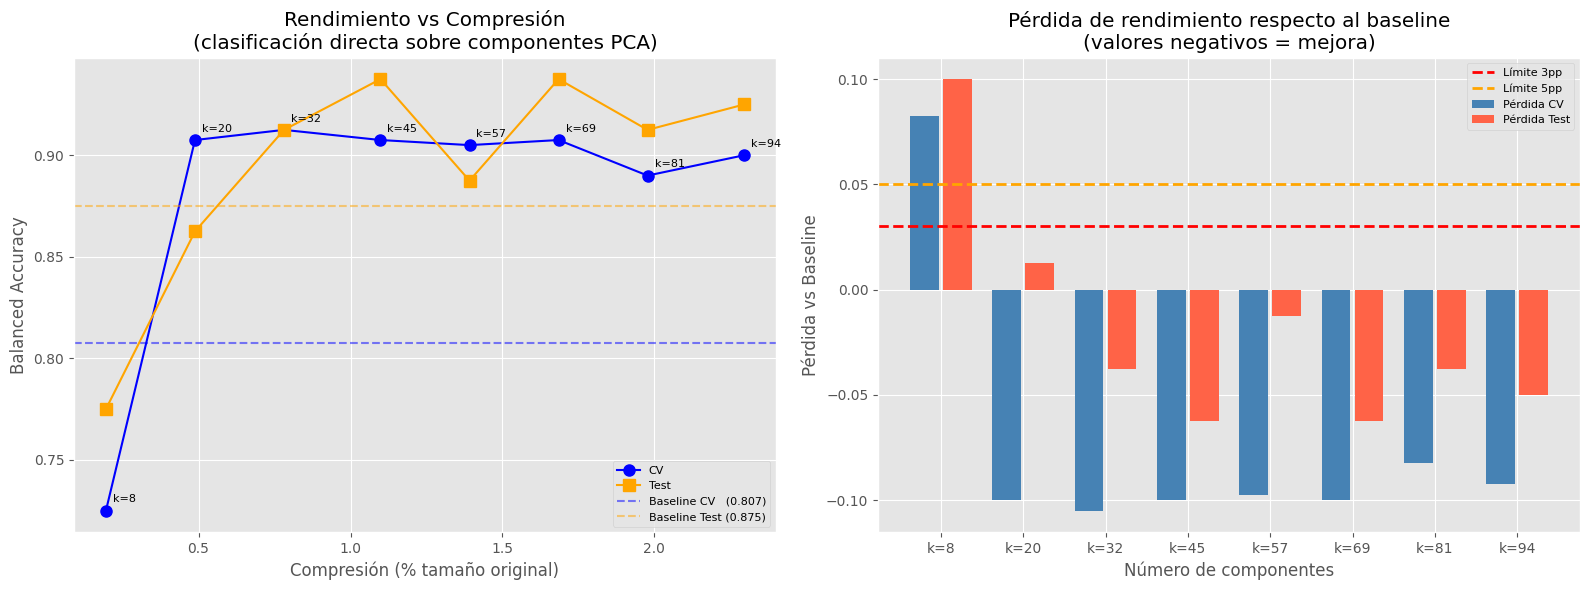

In [81]:
# Visualización de resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(result_tabla['compresion_%'], result_tabla['score_cv'],   'o-', color='blue',   markersize=8, label='CV')
ax1.plot(result_tabla['compresion_%'], result_tabla['score_test'], 's-', color='orange', markersize=8, label='Test')
ax1.axhline(y=baseline_cv,   color='blue',   linestyle='--', alpha=0.5, label=f'Baseline CV   ({baseline_cv:.3f})')
ax1.axhline(y=baseline_test, color='orange', linestyle='--', alpha=0.5, label=f'Baseline Test ({baseline_test:.3f})')
for _, r in result_tabla.iterrows():
    ax1.annotate(f"k={int(r['n_componentes'])}", (r['compresion_%'], r['score_cv']),
                 textcoords="offset points", xytext=(5, 6), fontsize=8)
ax1.set_xlabel('Compresión (% tamaño original)'); ax1.set_ylabel('Balanced Accuracy')
ax1.set_title('Rendimiento vs Compresión\n(clasificación directa sobre componentes PCA)')
ax1.legend(fontsize=8)

ax2 = axes[1]
x = np.arange(len(result_tabla))
ax2.bar(x - 0.2, -result_tabla['diff_cv_baseline'],   width=0.35, label='Pérdida CV',   color='steelblue')
ax2.bar(x + 0.2, -result_tabla['diff_test_baseline'], width=0.35, label='Pérdida Test', color='tomato')
ax2.axhline(y=0.03, color='red',    linestyle='--', linewidth=2, label='Límite 3pp')
ax2.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Límite 5pp')
ax2.set_xticks(x); ax2.set_xticklabels([f"k={int(k)}" for k in result_tabla['n_componentes']])
ax2.set_ylabel('Pérdida vs Baseline'); ax2.set_xlabel('Número de componentes')
ax2.set_title('Pérdida de rendimiento respecto al baseline\n(valores negativos = mejora)')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [82]:
# 5. Selección: máx. compresión con pérdida < 3pp en CV y Test
threshold = 0.03
mask = (result_tabla['diff_cv_baseline'] >= -threshold) & (result_tabla['diff_test_baseline'] >= -threshold)
candidates = result_tabla[mask]

if len(candidates) > 0:
    best = candidates.loc[candidates['compresion_%'].idxmin()]
    criterio = "3 puntos porcentuales"
else:
    mask5 = (result_tabla['diff_cv_baseline'] >= -0.05) & (result_tabla['diff_test_baseline'] >= -0.05)
    candidates = result_tabla[mask5]
    best = candidates.loc[candidates['compresion_%'].idxmin()] if len(candidates) > 0 else result_tabla.iloc[-1]
    criterio = "5 puntos porcentuales"

best_k_part2 = int(best['n_componentes'])
texto= f"SELECCIÓN #2  (máx. compresión, pérdida < {criterio})"
print("=" * len(texto))
print(f"{texto}")
print("=" * len(texto))
print(f"  Número de componentes elegido: {best_k_part2}")
print(f"  Compresión:                    {best['compresion_%']:.3f}% del tamaño original")
print(f"  Balanced Accuracy CV:          {best['score_cv']:.4f}  (Δ = {best['diff_cv_baseline']:+.4f})")
print(f"  Balanced Accuracy Test:        {best['score_test']:.4f}  (Δ = {best['diff_test_baseline']:+.4f})")
print(f"\n  → Las microcámaras clasifican con {best_k_part2} componentes PCA,")
print(f"    enviando solo el {best['compresion_%']:.3f}% del tamaño original.")

SELECCIÓN #2  (máx. compresión, pérdida < 3 puntos porcentuales)
  Número de componentes elegido: 20
  Compresión:                    0.488% del tamaño original
  Balanced Accuracy CV:          0.9075  (Δ = +0.1000)
  Balanced Accuracy Test:        0.8625  (Δ = -0.0125)

  → Las microcámaras clasifican con 20 componentes PCA,
    enviando solo el 0.488% del tamaño original.


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.


In [83]:
porcentaje_compresion = np.arange(0.001,0.0102, 0.002)
num_components_comp = (porcentaje_compresion * num_features).astype(int)
print(f"\nNúmero de componentes a probar: {num_components_comp}")


Número de componentes a probar: [ 4 12 20 28 36]


2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.

In [84]:
# Hacemos el entreno de un modelo con cada una de las reducciones de variables, teniendo en cuenta que se encuentran en orden creciente de varianza explicada
results_comp = []
k_model = RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42, n_jobs=-1)
for n_comp in num_components_comp:
    pca_fit = PCA(n_components=n_comp, random_state=42)
   
    # Comprimir y descomprimir train
    X_train_comp  = pca_fit.fit_transform(X_train)
    X_train_unzip = pca_fit.inverse_transform(X_train_comp)

    # Comprimir y descomprimir test (mismo PCA, ajustado solo en train)
    X_test_comp  = pca_fit.transform(X_test)
    X_test_unzip = pca_fit.inverse_transform(X_test_comp)

    # Entrenar sobre imágenes reconstruidas
    clf_rec = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
    clf_rec.fit(X_train_unzip, y_train)
    test_score = balanced_accuracy_score(y_test, clf_rec.predict(X_test_unzip))

    results_comp.append({
        'n_componentes':     n_comp,
        'score_test':        round(test_score, 4),
        'compresion_%':      round(n_comp / num_features * 100, 4),
        'diff_vs_baseline':  round(test_score - baseline_test, 4)
    })
    print(f"  k={n_comp:3d} | Compresión={n_comp/num_features*100:.3f}% | Test={test_score:.4f}  (Δ={test_score-baseline_test:+.4f})")



  k=  4 | Compresión=0.098% | Test=0.6750  (Δ=-0.2000)
  k= 12 | Compresión=0.293% | Test=0.8875  (Δ=+0.0125)
  k= 20 | Compresión=0.488% | Test=0.9250  (Δ=+0.0500)
  k= 28 | Compresión=0.684% | Test=0.9125  (Δ=+0.0375)
  k= 36 | Compresión=0.879% | Test=0.9250  (Δ=+0.0500)


3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 

In [86]:
# 3. DataFrame de resultados
df_results3 = pd.DataFrame(results_comp)
display(df_results3.style
        .background_gradient(cmap='RdYlGn', subset=['score_test'])
        .format({'score_test': '{:.4f}', 'compresion_%': '{:.3f}%', 'diff_vs_baseline': '{:+.4f}'}))

,n_componentes,score_test,compresion_%,diff_vs_baseline
0,4,0.6750,0.098%,-0.2000
1,12,0.8875,0.293%,+0.0125
2,20,0.9250,0.488%,+0.0500
3,28,0.9125,0.684%,+0.0375
4,36,0.9250,0.879%,+0.0500


4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

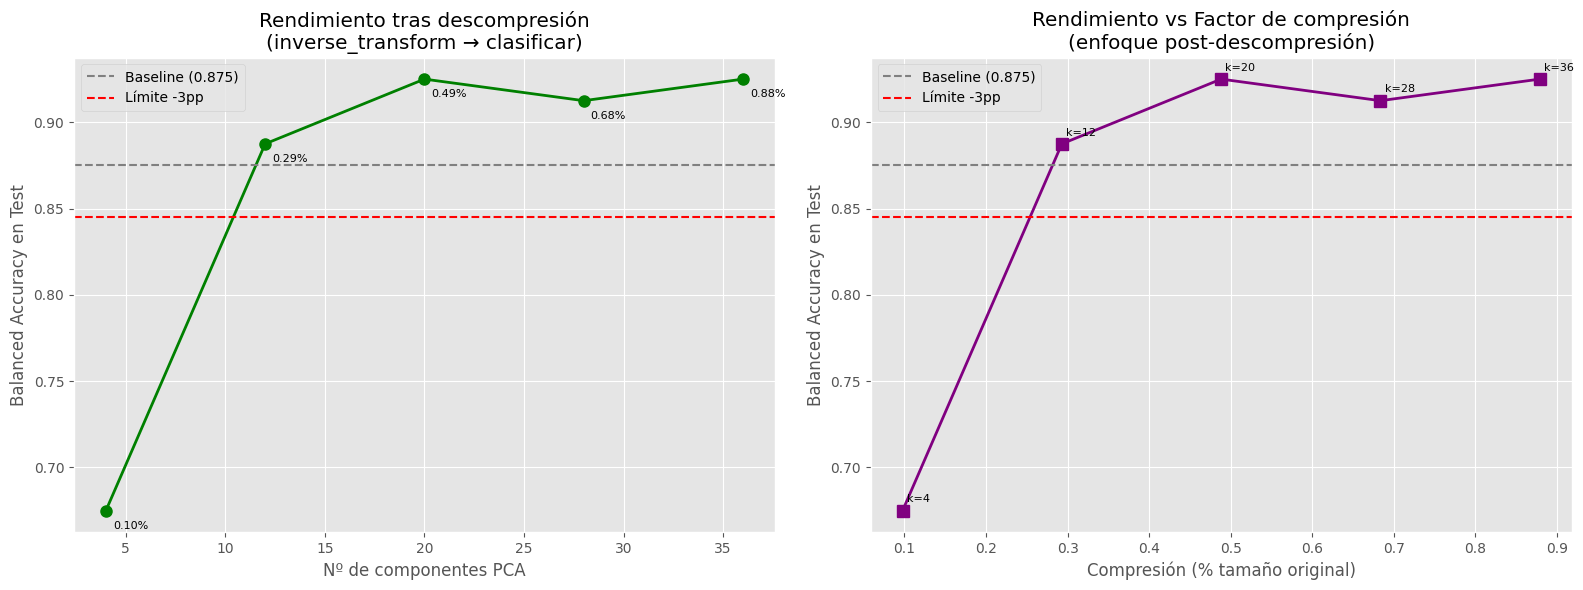

RECOMENDACIÓN SECCIÓN #3
  Con pérdida < 3pp en test, el óptimo es k = 12
  Compresión:              0.293% del tamaño original
  Balanced Accuracy Test:  0.8875  (Δ = +0.0125)

  → Las cámaras envían 12 valores por imagen (vs 4096 originales).
    El servidor los reconstruye con inverse_transform y clasifica.


In [88]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(df_results3['n_componentes'], df_results3['score_test'],
         'o-', color='green', markersize=8, linewidth=2)
ax1.axhline(y=baseline_test,        color='gray', linestyle='--', label=f'Baseline ({baseline_test:.3f})')
ax1.axhline(y=baseline_test - 0.03, color='red',  linestyle='--', label='Límite -3pp')
for _, r in df_results3.iterrows():
    ax1.annotate(f"{r['compresion_%']:.2f}%", (r['n_componentes'], r['score_test']),
                 textcoords="offset points", xytext=(5, -13), fontsize=8)
ax1.set_xlabel('Nº de componentes PCA'); ax1.set_ylabel('Balanced Accuracy en Test')
ax1.set_title('Rendimiento tras descompresión\n(inverse_transform → clasificar)'); ax1.legend()

ax2 = axes[1]
ax2.plot(df_results3['compresion_%'], df_results3['score_test'],
         's-', color='purple', markersize=8, linewidth=2)
ax2.axhline(y=baseline_test,        color='gray', linestyle='--', label=f'Baseline ({baseline_test:.3f})')
ax2.axhline(y=baseline_test - 0.03, color='red',  linestyle='--', label='Límite -3pp')
for _, r in df_results3.iterrows():
    ax2.annotate(f"k={int(r['n_componentes'])}", (r['compresion_%'], r['score_test']),
                 textcoords="offset points", xytext=(3, 6), fontsize=8)
ax2.set_xlabel('Compresión (% tamaño original)'); ax2.set_ylabel('Balanced Accuracy en Test')
ax2.set_title('Rendimiento vs Factor de compresión\n(enfoque post-descompresión)'); ax2.legend()

plt.tight_layout(); plt.show()

# 4. Recomendación
print("=" * 60)
print("RECOMENDACIÓN SECCIÓN #3")
print("=" * 60)
threshold3 = 0.03
mask3      = df_results3['diff_vs_baseline'] >= -threshold3
candidates3 = df_results3[mask3]

if len(candidates3) > 0:
    best3 = candidates3.loc[candidates3['compresion_%'].idxmin()]
    best_k_part3 = int(best3['n_componentes'])
    print(f"  Con pérdida < 3pp en test, el óptimo es k = {best_k_part3}")
    print(f"  Compresión:              {best3['compresion_%']:.3f}% del tamaño original")
    print(f"  Balanced Accuracy Test:  {best3['score_test']:.4f}  (Δ = {best3['diff_vs_baseline']:+.4f})")
    print(f"\n  → Las cámaras envían {best_k_part3} valores por imagen (vs {num_features} originales).")
    print(f"    El servidor los reconstruye con inverse_transform y clasifica.")
else:
    best3 = df_results3.loc[df_results3['diff_vs_baseline'].idxmax()]
    best_k_part3 = int(best3['n_componentes'])
    print(f"  Ningún candidato cumple la restricción de 3pp.")
    print(f"  Mejor disponible: k={best_k_part3}, score={best3['score_test']:.4f}")
    print(f"  Compresión: {best3['compresion_%']:.3f}% del tamaño original")

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)

Varianza explicada por PC1: 24.22%
Varianza explicada por PC2: 14.05%


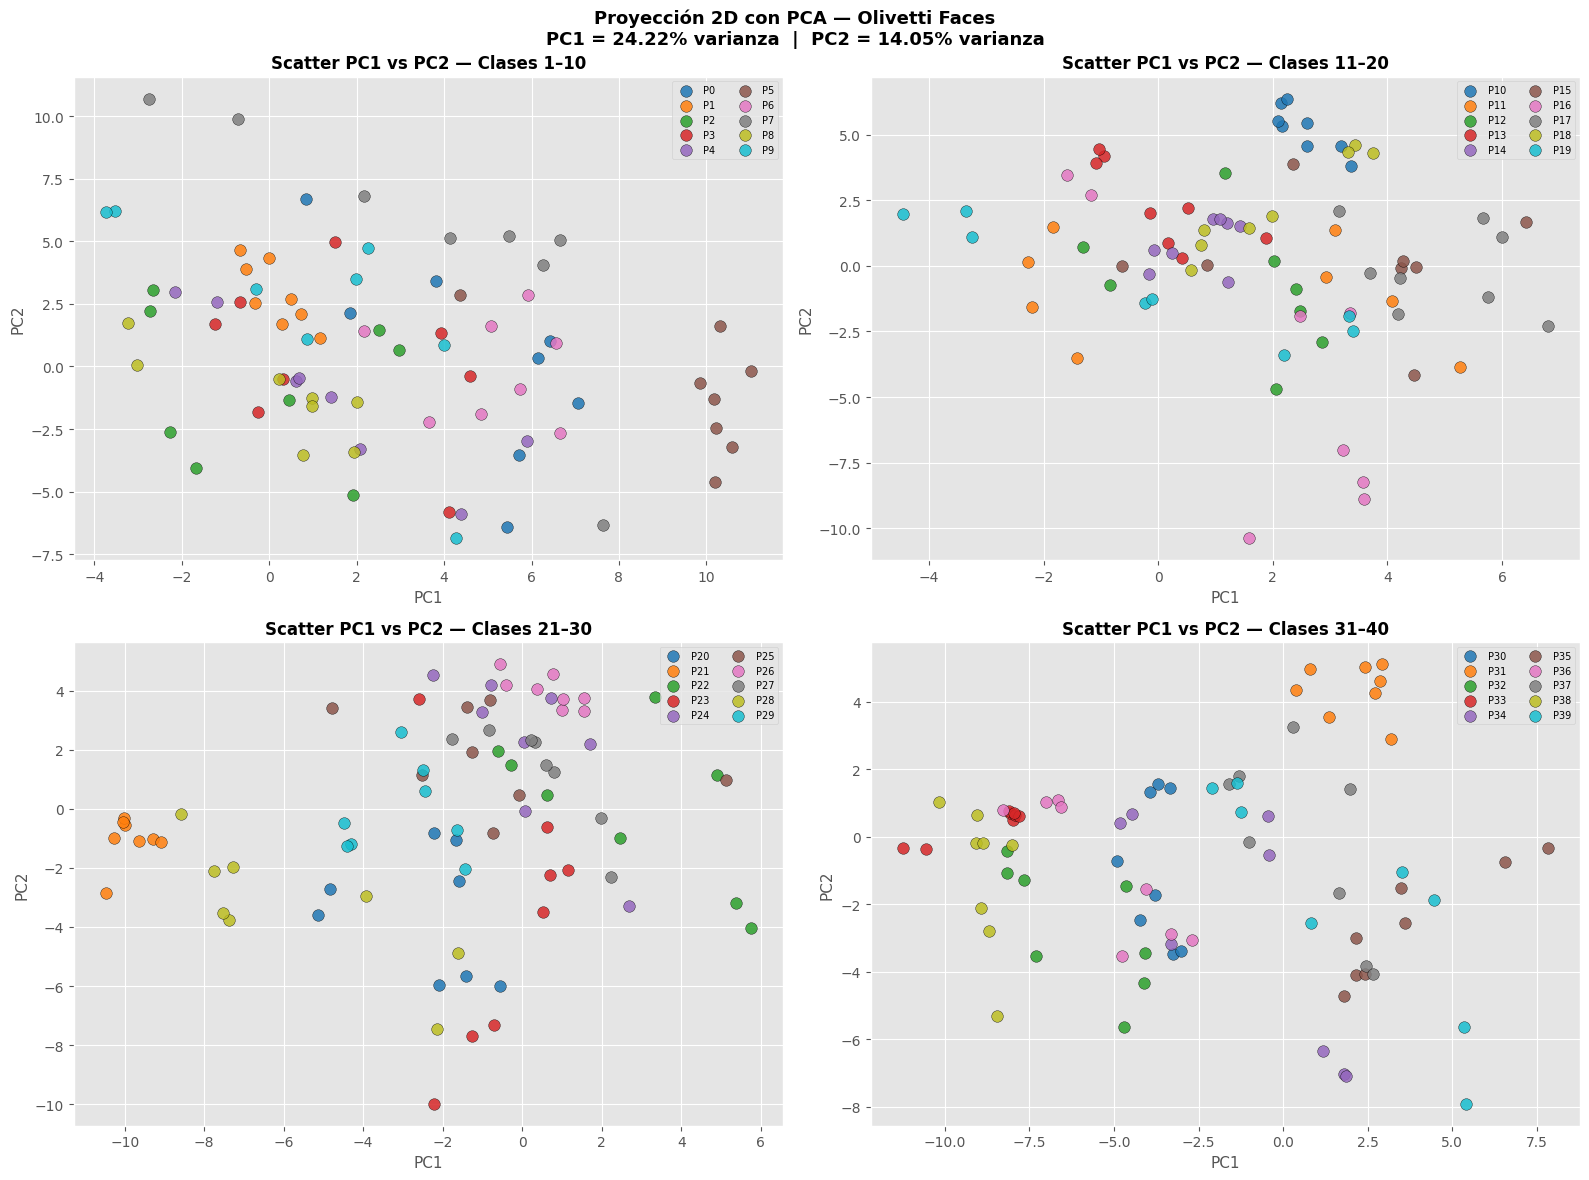

In [90]:
# EXTRA 1: Scatter plot de las 2 primeras componentes PCA
# Proyección a 2D con la PCA del mejor modelo (best_k_part2)
# 4 gráficos con 10 clases cada uno, coloreados por persona

pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")

colors_tab    = plt.cm.tab10(np.linspace(0, 1, 10))
class_groups  = [range(0, 10), range(10, 20), range(20, 30), range(30, 40)]
group_labels  = ['Clases 1–10', 'Clases 11–20', 'Clases 21–30', 'Clases 31–40']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, class_range, label in zip(axes.flat, class_groups, group_labels):
    for i, cls in enumerate(class_range):
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   color=colors_tab[i], label=f'P{cls}',
                   alpha=0.85, s=70, edgecolors='k', linewidths=0.3)
    ax.set_xlabel('PC1', fontsize=11); ax.set_ylabel('PC2', fontsize=11)
    ax.set_title(f'Scatter PC1 vs PC2 — {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7, ncol=2)

plt.suptitle(
    f'Proyección 2D con PCA — Olivetti Faces\n'
    f'PC1 = {pca_2d.explained_variance_ratio_[0]:.2%} varianza  |  '
    f'PC2 = {pca_2d.explained_variance_ratio_[1]:.2%} varianza',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()

2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

In [124]:
# EXTRA 2: Función para visualizar caras originales vs reconstruidas (inverse_transform)

def visualizar_caras(X, y, n_faces=5, k_values=[4, 8, 15, 25, 41, 150, 320]):
    """
    Muestra n_faces caras, comparando la imagen original con su reconstrucción
    (PCA inverse_transform) para cada número de componentes en k_values.
    La PCA se ajusta sobre X (debe ser el conjunto de entrenamiento).
    """
     # Normalizar a numpy para que X[idx] seleccione filas, no columnas
    X = np.asarray(X)
    y = np.asarray(y)
    # Una imagen de cada una de las primeras n_faces personas
    indices = [np.where(y == cls)[0][0] for cls in range(n_faces)]
    print("Indices seleccionados:", indices)
    # Pre-calcular reconstrucciones una sola vez por k (eficiente)
    recs = {}
    for k in k_values:
        print(f"Procesando reconstrucción para k={k}...")
        k_safe = min(k, min(X.shape[0] - 1, X.shape[1]))
        pca_k  = PCA(n_components=k_safe, random_state=42)
        X_rec  = pca_k.inverse_transform(pca_k.fit_transform(X))
        recs[k] = np.clip(X_rec, 0, 1)

    n_rows = n_faces
    n_cols = len(k_values) + 1   # +1 para columna "Original"
    print(f"Visualizando {n_rows} caras con {n_cols} columnas (original + {len(k_values)} reconstrucciones)...")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.8 * n_rows))

    for row, idx in enumerate(indices):
        # Columna 0: imagen original
        idx= idx.tolist()
        print(f"Mostrando cara original y reconstrucciones para índice {idx} (P{y[idx]})...")
        #Accedemos al indice teniendo en cuenta que X es un Dataframe
        axes[row, 0].imshow(X[idx].reshape(64, 64), cmap='gray')
        axes[row, 0].set_title(f'Original\nP{y[idx]}', fontsize=8)
        axes[row, 0].axis('off')
        # Columnas 1…: reconstrucciones para cada k
        for col, k in enumerate(k_values, start=1):
            axes[row, col].imshow(recs[k][idx].reshape(64, 64), cmap='gray')
            axes[row, col].set_title(f'k={k}\n({k/X.shape[1]*100:.2f}%)', fontsize=8)
            axes[row, col].axis('off')

    plt.suptitle(
        'Caras originales vs reconstruidas (PCA inverse_transform)\n'
        '% = porcentaje del tamaño original transmitido por las cámaras',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout(); plt.show()


In [122]:
# Visualizamos para los k de la Sección #3 + k=150 y k=320 (claridad máxima)
k_extra = num_components_comp.tolist() + [150, 320]
k_extra

[4, 12, 20, 28, 36, 150, 320]

Visualizando reconstrucciones para k = [4, 12, 20, 28, 36, 150, 320]

Indices seleccionados: [np.int64(35), np.int64(10), np.int64(132), np.int64(2), np.int64(56)]
Procesando reconstrucción para k=4...
Procesando reconstrucción para k=12...
Procesando reconstrucción para k=20...
Procesando reconstrucción para k=28...
Procesando reconstrucción para k=36...
Procesando reconstrucción para k=150...
Procesando reconstrucción para k=320...
Visualizando 5 caras con 8 columnas (original + 7 reconstrucciones)...
Mostrando cara original y reconstrucciones para índice 35 (P0)...
Mostrando cara original y reconstrucciones para índice 10 (P1)...
Mostrando cara original y reconstrucciones para índice 132 (P2)...
Mostrando cara original y reconstrucciones para índice 2 (P3)...
Mostrando cara original y reconstrucciones para índice 56 (P4)...


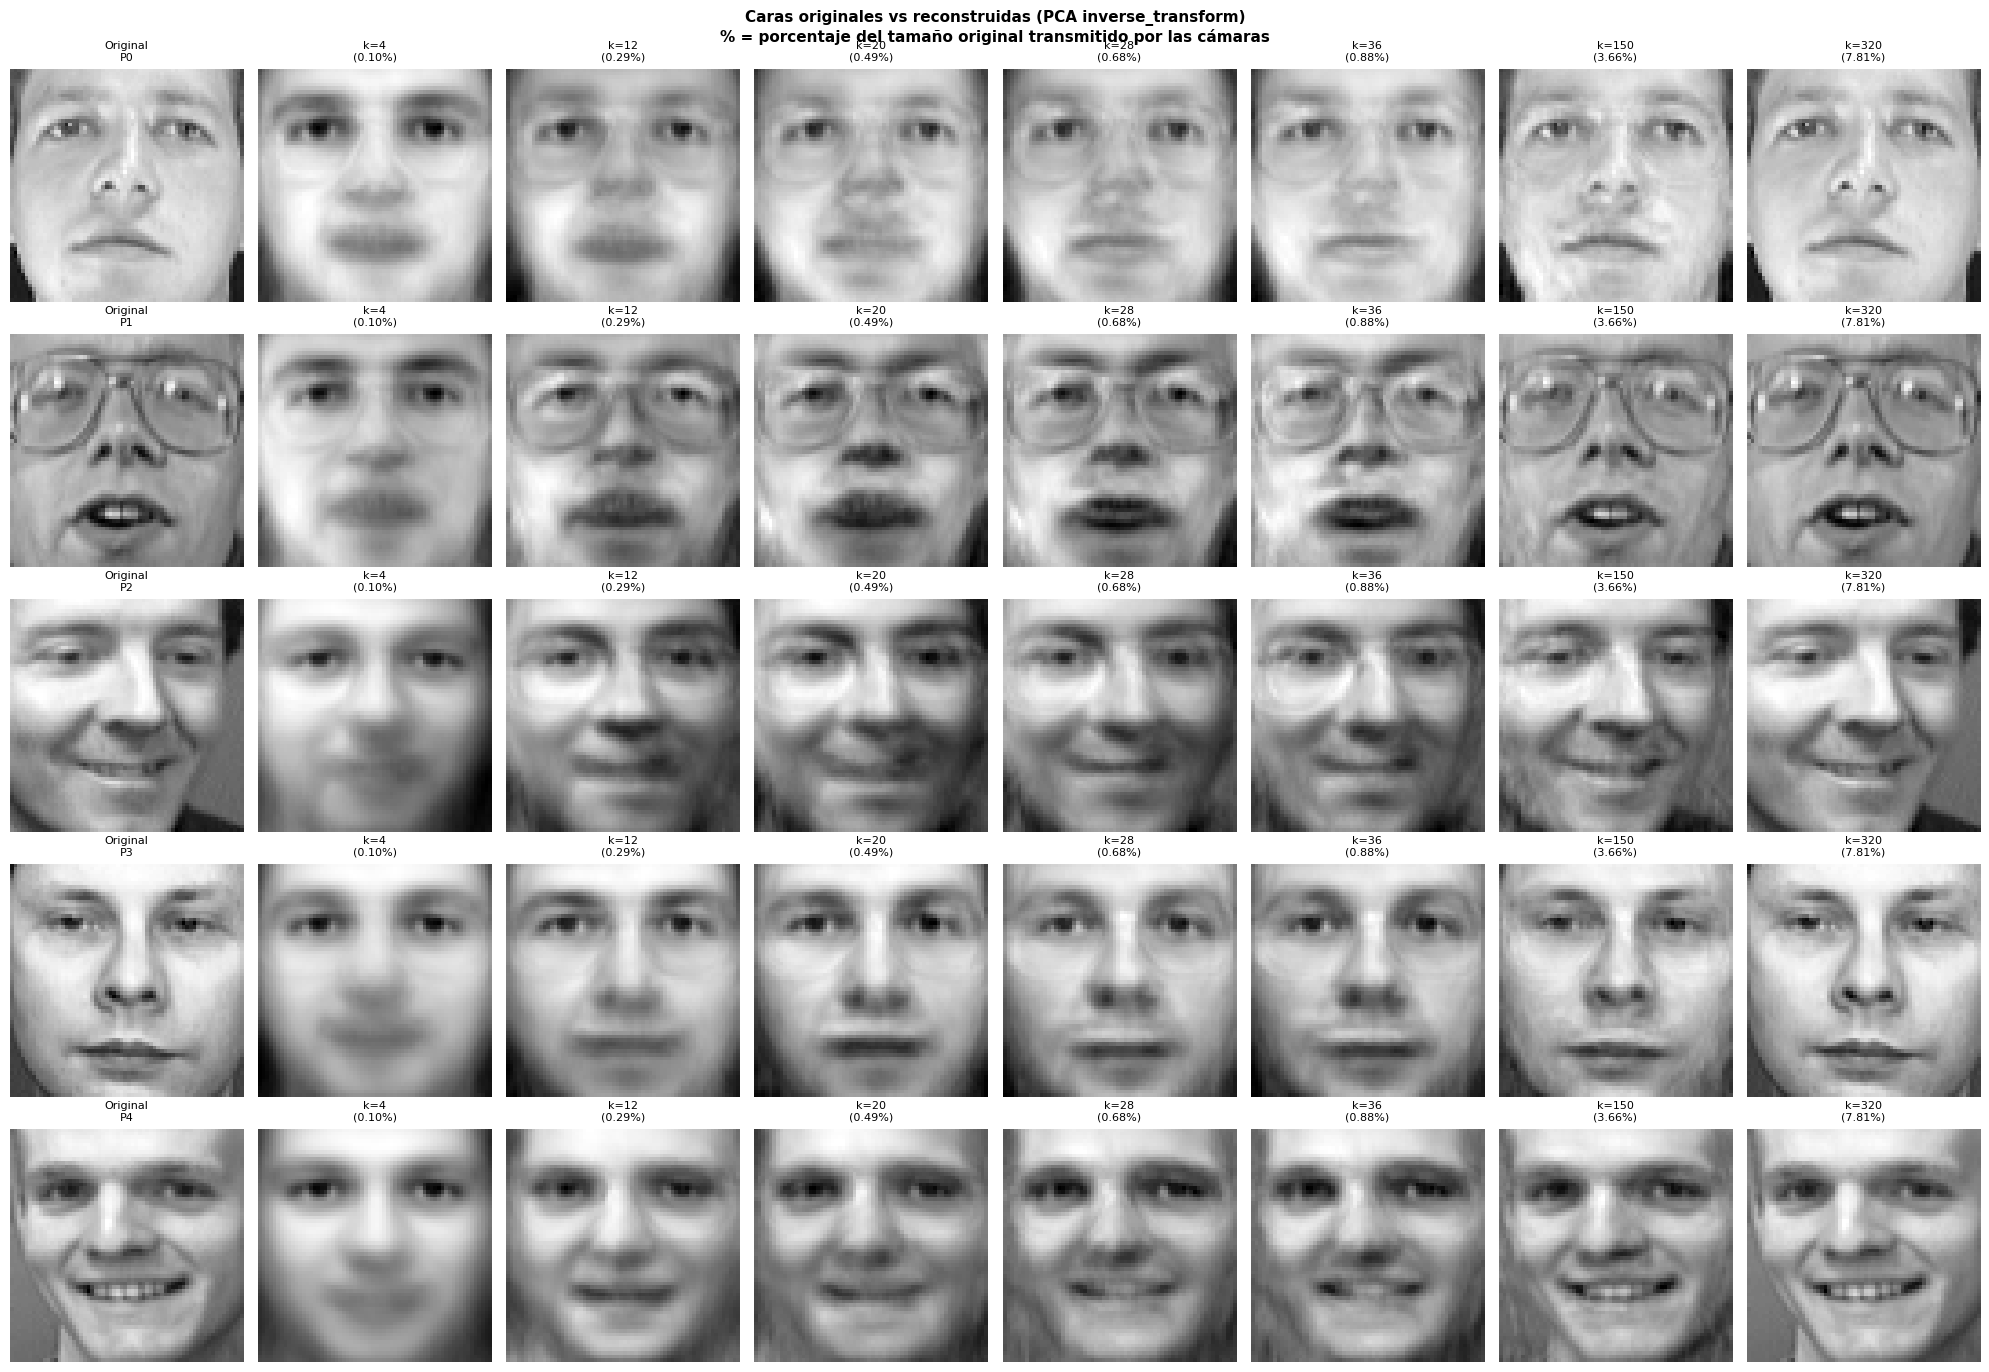

In [125]:
print(f"Visualizando reconstrucciones para k = {k_extra}\n")
visualizar_caras(X_train, y_train, n_faces=5, k_values=k_extra)